# Figure 3 — NeuroPixels Application & Results

Compiled, reproducible version of panels B (within-subject), C (LOSO), and D (spatial map)
of the NeuroPixels arousal-tracking figure. All feature construction, SFA fitting, and
cross-validation logic is imported from this repo's own `src/` package
(`src/neuropixels_data.py`, `src/pearson_edge.py`, `src/sfa.py`) rather than re-inlined here.
Raw NeuroPixels data (~39GB) is not bundled in this repo -- see the `DATA_ROOT` configuration
cell below to point at your local copy.


## Configuration

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

# src/ lives at this repo's root, a direct sibling of this notebook.
sys.path.insert(0, str(Path.cwd()))

from src.neuropixels_data import list_subjects, load_subject_lfp
from src.pearson_edge import build_edges
from src.features import build_feature
from src.util import moving_average_centered
from src.sweeps import component0_scores
from src.sfa import global_fit, loso_cv, affine_align, pearson_r, r2_score

import os

os.environ["NEUROPIXELS_DATA_ROOT"] = "/Users/ritviksharma/Projects/code_pSFA/experiments/neuropixels/functional_connectivity"
_data_root_env = os.environ.get("NEUROPIXELS_DATA_ROOT")
assert _data_root_env, "Set the NEUROPIXELS_DATA_ROOT environment variable to your local NeuroPixels data copy."
DATA_ROOT = Path(_data_root_env)
assert DATA_ROOT.exists(), f"Neuropixels data not found at {DATA_ROOT} -- check NEUROPIXELS_DATA_ROOT."
MEDIA_DIR = Path("outputs/figures/neuropixels")
CACHE_DIR = Path("outputs/results/neuropixels")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

DOWNSAMPLE_FACTOR = 10     # 1250 Hz -> 125 Hz
EDGE_WIN          = 1501   # rolling window (samples at downsampled rate) ~ 12 s
N_COMPONENTS      = 3      # within-subject / LOSO SFA components (matches source notebook)

POOL_AREAS = ["VISp", "VISrl", "VISal", "VISam"]                     # 4-area pool, LOSO
CANON      = ["VISp", "VISl", "VISrl", "VISal", "VISam", "VISpm"]    # 6-area pool, spatial map

CORRUPTED_SIDS = ["786091066", "829720705", "831882777", "835479236", "839068429"]
# near-zero variance / bad recordings; kept in raw tables, excluded from summary plots/statistics

def drop_corrupted(df):
    return df[~df.index.astype(str).isin(CORRUPTED_SIDS)]

def zscore(x):
    return (x - np.nanmean(x)) / np.nanstd(x)

POS = {
    "VISp" : (0.57, 0.28), "VISl" : (0.28, 0.45), "VISal": (0.27, 0.67),
    "VISrl": (0.47, 0.84), "VISam": (0.73, 0.78), "VISpm": (0.78, 0.53),
}
BG_IMAGE_PATH = MEDIA_DIR / "mouse_cortex_blank.png"


BG_IMAGE = mpimg.imread(BG_IMAGE_PATH) if BG_IMAGE_PATH.exists() else None

ACCENT="#2a6f72"; ACCENT_D="#1d4f51"; GOLD="#c58a3d"; GOLD_D="#8f5f24"
MUTED="#8a8f99"; INK="#1f2328"; INK_SOFT="#4a4f57"; RULE="#e3e0d8"

subjects = list_subjects(DATA_ROOT)
print(f"EDGE_WIN = {EDGE_WIN} samples =~ {EDGE_WIN / (1250/DOWNSAMPLE_FACTOR):.0f} s "
      f"at {1250//DOWNSAMPLE_FACTOR} Hz")
print(f"Found {len(subjects)} candidate subject(s) "
      f"({len(CORRUPTED_SIDS)} corrupted subject(s) kept in tables, excluded from summaries).")
print(f"Background image found: {BG_IMAGE is not None}")


EDGE_WIN = 1501 samples =~ 12 s at 125 Hz
Found 21 candidate subject(s) (5 corrupted subject(s) kept in tables, excluded from summaries).
Background image found: True


## Panel B — Within-subject

Correlation-edge p-SFA reconstructs pupil-linked arousal within-subject, compared against a
per-node sliding-window-variance baseline. Both the correlation edges and the pupil target are
smoothed with the same `EDGE_WIN` rolling window.

In [2]:
within_rows = []
SUBJECT_DATA_CACHE = {}   # sid -> (X_s, d_s_raw, t_s); reused by panel D loop below is NOT shared
                          # (panel D restricts to CANON areas (for grouping common areas), a different column set)
for sid in subjects:
    print(sid)
    try:

        out = load_subject_lfp(DATA_ROOT / sid, DOWNSAMPLE_FACTOR, area_filter=None)
        if out is None:
            continue
        X_s, d_s, t_s, areas_s = out
        SUBJECT_DATA_CACHE[sid] = (X_s, d_s, t_s)
        d_sm = moving_average_centered(d_s[:, None], EDGE_WIN)[:, 0]

        Rho   = build_feature("edges-corr", X_s, EDGE_WIN)
        X_var = build_feature("node-var", X_s, EDGE_WIN)

        T = min(len(d_sm), Rho.shape[0], X_var.shape[0])
        d_, Rho_, X_var_ = d_sm[:T], Rho[:T], X_var[:T]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r2_corr, _ = component0_scores(Rho_,   d_, n_components=N_COMPONENTS)
            r2_var, _  = component0_scores(X_var_, d_, n_components=N_COMPONENTS)

        within_rows.append(dict(subject=sid, R2_corr=r2_corr, R2_nodevar=r2_var))
    except Exception as exc:
        print(f"  {sid}: [skip] {exc}")

within_df = pd.DataFrame(within_rows).set_index("subject")
within_df.to_csv(CACHE_DIR / "within_subject_smoothed.csv")
print(f"n = {len(within_df)} subjects")
display(within_df.round(3))


766640955
767871931
771160300
771990200
774875821
778240327
778998620
779839471
781842082
786091066
787025148
789848216
793224716
794812542
816200189
829720705
831882777
835479236
839068429
839557629
847657808
n = 20 subjects


,R2_corr,R2_nodevar
subject,,
766640955,0.608,0.389
767871931,0.728,0.668
771160300,0.862,0.458
771990200,0.750,0.496
774875821,0.728,0.518
778240327,0.729,0.699
778998620,0.832,0.505
779839471,0.594,0.349
781842082,0.857,0.576


findfont: Failed to find font weight semibold, now using 700.


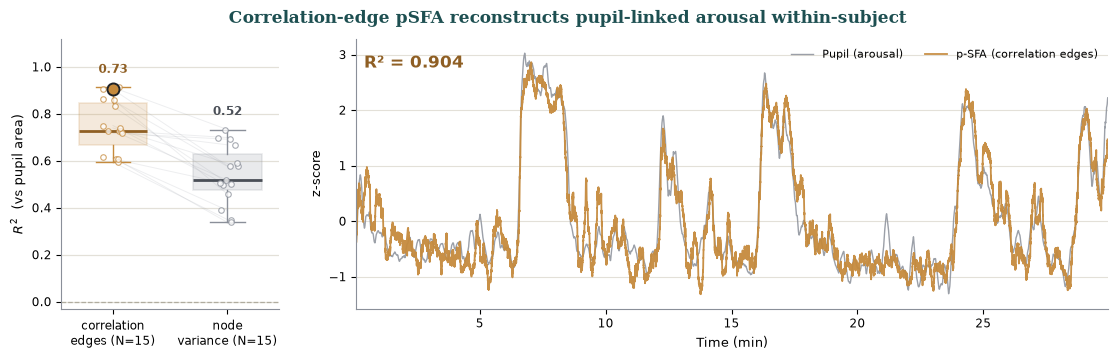

Plotted subject: 793224716  (R2 = 0.904)   [best subject overall: 789848216]
median R2: correlation edges = 0.729   node variance = 0.518


In [3]:
SELECTED_SID = '793224716'  # set to a subject id string to plot that subject; None = auto-pick best

gdf         = drop_corrupted(within_df)
corr_vals   = gdf["R2_corr"].dropna().values
nv_vals     = gdf["R2_nodevar"].dropna().values

BEST_SID = drop_corrupted(within_df)["R2_corr"].idxmax()
PLOT_SID = SELECTED_SID if SELECTED_SID is not None else BEST_SID
if PLOT_SID not in SUBJECT_DATA_CACHE:
    raise ValueError(f"{PLOT_SID!r} not in SUBJECT_DATA_CACHE -- available: {sorted(SUBJECT_DATA_CACHE)}")

X_b, d_b, t_b = SUBJECT_DATA_CACHE[PLOT_SID]
d_sm_b = moving_average_centered(d_b[:, None], EDGE_WIN)[:, 0]
Rho_b = build_feature("edges-corr", X_b, EDGE_WIN)
n_b = min(len(d_sm_b), Rho_b.shape[0])
Rho_b, d_sm_b = Rho_b[:n_b], d_sm_b[:n_b]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    r2_b, absr_b, y_b_raw = component0_scores(Rho_b, d_sm_b, n_components=N_COMPONENTS,
                                              return_component=True)
    y_b, _, _ = affine_align(y_b_raw, d_sm_b)  # sign-fix + scale for the overlay plot below
half = (EDGE_WIN - 1) // 2
t_sm = (t_b[half: half + len(d_sm_b)] - t_b[0]) / 60.0

fig = plt.figure(figsize=(13.5, 3.6))
gs  = fig.add_gridspec(1, 2, width_ratios=[0.55, 1.9], wspace=0.16, top=0.86)
axL = fig.add_subplot(gs[0]); axR = fig.add_subplot(gs[1])

axL.set_axisbelow(True); axL.yaxis.grid(True, color=RULE, lw=0.9)
groups = [(corr_vals, GOLD, GOLD_D), (nv_vals, MUTED, INK_SOFT)]
rng = np.random.default_rng(0)
for pos, (vals, col, cold) in enumerate(groups, 1):
    bp = axL.boxplot(vals, positions=[pos], widths=0.6, patch_artist=True,
                      showfliers=False, whis=(0, 100),
                      medianprops=dict(color=cold, lw=2.0), boxprops=dict(edgecolor=col, lw=1.2),
                      whiskerprops=dict(color=col, lw=1.0), capprops=dict(color=col, lw=1.0))
    bp["boxes"][0].set_facecolor(col); bp["boxes"][0].set_alpha(0.18)
    axL.scatter(np.full(len(vals), pos) + rng.uniform(-0.09, 0.09, len(vals)), vals, s=16,
                color="white", edgecolors=col, linewidths=0.8, zorder=3, alpha=0.75)
    axL.text(pos, vals.max() + 0.05, f"{np.median(vals):.2f}", va="bottom", ha="center",
             fontsize=8.5, color=cold, fontweight="bold")
# faded lines connecting each subject's pair of values across the two categories
for sid in gdf.index:
    v_corr, v_nv = gdf.loc[sid, "R2_corr"], gdf.loc[sid, "R2_nodevar"]
    if np.isfinite(v_corr) and np.isfinite(v_nv):
        axL.plot([1, 2], [v_corr, v_nv], color=MUTED, alpha=0.15, lw=0.7, zorder=1)
# highlight the plotted subject's correlation-edges point only (not node variance)
if PLOT_SID in gdf.index:
    v_corr = gdf.loc[PLOT_SID, "R2_corr"]
    axL.scatter([1], [v_corr], s=75, facecolor=GOLD, edgecolors=INK, linewidths=1.4, zorder=4)
axL.axhline(0, color="#b0ac9f", lw=0.9, ls="--", zorder=1)
axL.set_xticks([1, 2])
axL.set_xticklabels([f"correlation\nedges (N={len(corr_vals)})", f"node\nvariance (N={len(nv_vals)})"], fontsize=8.5)
axL.set_xlim(0.55, 2.45); axL.set_ylim(-0.03, 1.12)
axL.set_ylabel(r"$R^2$  (vs pupil area)", fontsize=9.5)
axL.tick_params(labelsize=8.5)
axL.spines[["top", "right"]].set_visible(False); axL.spines[["left", "bottom"]].set_color(MUTED)

axR.set_axisbelow(True); axR.yaxis.grid(True, color=RULE, lw=0.8)
axR.plot(t_sm, zscore(d_sm_b), color=MUTED, lw=1.0, alpha=0.85, label="Pupil (arousal)")
axR.plot(t_sm, zscore(y_b),    color=GOLD,  lw=1.3, alpha=0.95, label="p-SFA (correlation edges)")
axR.text(0.01, 0.94, f"R\u00b2 = {r2_b:.3f}",
         transform=axR.transAxes, ha="left", va="top", fontsize=12, color=GOLD_D, fontweight="bold")
axR.set_xlim(t_sm.min(), t_sm.max()); axR.margins(y=0.06)
axR.set_xlabel("Time (min)", fontsize=9.5); axR.set_ylabel("z-score", fontsize=9.5)
axR.tick_params(labelsize=8.5)
axR.legend(loc="upper right", frameon=False, fontsize=8, ncol=2)
axR.spines[["top", "right"]].set_visible(False); axR.spines[["left", "bottom"]].set_color(MUTED)

fig.suptitle("Correlation-edge pSFA reconstructs pupil-linked arousal within-subject",
             fontfamily="serif", color=ACCENT_D, fontsize=12, fontweight="semibold", y=0.94)
fname = "fig3b_within_subject" if PLOT_SID == BEST_SID else f"fig3b_within_subject_{PLOT_SID}"
fig.savefig(MEDIA_DIR / f"{fname}.svg", transparent=True, bbox_inches="tight")
fig.savefig(MEDIA_DIR / f"{fname}.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()

print(f"Plotted subject: {PLOT_SID}  (R2 = {r2_b:.3f})   [best subject overall: {BEST_SID}]")
print(f"median R2: correlation edges = {np.median(corr_vals):.3f}   node variance = {np.median(nv_vals):.3f}")

## Panel C — Leave-one-subject-out (LOSO)

Fit the block-aware SFA model on N-1 subjects (pooled over the 4-area `POOL_AREAS` subset, so
every subject contributes the same feature width), freeze the weights, and apply cold to the
held-out subject.

In [4]:
def subject_corr_edges(X_ds, edge_win):
    return build_feature("edges-corr", X_ds, edge_win), None

def subject_nodevar_features(X_ds, edge_win):
    return build_feature("node-var", X_ds, edge_win), None

def align_pupil(d_raw, n_feat, edge_win):
    d = moving_average_centered(d_raw[:, None], edge_win)[:, 0]
    return d[:n_feat]

SUBJECT_POOL_CACHE = {}

def get_subject_pool(sid):
    if sid not in SUBJECT_POOL_CACHE:
        SUBJECT_POOL_CACHE[sid] = load_subject_lfp(DATA_ROOT / sid, DOWNSAMPLE_FACTOR,
                                                     area_filter=POOL_AREAS, strict=True)
    return SUBJECT_POOL_CACHE[sid]

def build_pool_feature(builder, edge_win=EDGE_WIN):
    F_dict, d_dict = {}, {}
    for sid in subjects:
        print(sid)
        loaded = get_subject_pool(sid)
        if loaded is None:
            continue
        X_ds, d_raw, _, _ = loaded
        F, _ = builder(X_ds, edge_win)
        d_aligned = align_pupil(d_raw, F.shape[0], edge_win)
        n = min(len(d_aligned), F.shape[0])
        F_dict[sid] = F[:n]; d_dict[sid] = d_aligned[:n]
    return F_dict, d_dict

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    F_corr, d_corr = build_pool_feature(subject_corr_edges)
    F_nv,   d_nv   = build_pool_feature(subject_nodevar_features)

loso_corr = loso_cv(F_corr, d_corr, N_COMPONENTS)
loso_nv   = loso_cv(F_nv,   d_nv,   N_COMPONENTS)

loso_df = pd.DataFrame({"R2_corr": loso_corr, "R2_nodevar": loso_nv})
loso_df.to_csv(CACHE_DIR / "loso_smoothed.csv")
print(f"Pool {POOL_AREAS}: n = {len(loso_df)} eligible subjects")
display(loso_df.round(3))


766640955
767871931
771160300
771990200
774875821
778240327
778998620
779839471
781842082
786091066
787025148
789848216
793224716
794812542
816200189
829720705
831882777
835479236
839068429
839557629
847657808
766640955
767871931
771160300
771990200
774875821
778240327
778998620
779839471
781842082
786091066
787025148
789848216
793224716
794812542
816200189
829720705
831882777
835479236
839068429
839557629
847657808
Pool ['VISp', 'VISrl', 'VISal', 'VISam']: n = 13 eligible subjects


,R2_corr,R2_nodevar
766640955,0.509,0.004
767871931,0.733,0.004
771990200,0.833,0.556
774875821,0.679,0.116
778240327,0.691,0.096
778998620,0.778,0.166
781842082,0.844,0.251
786091066,0.034,0.421
787025148,0.639,0.000
789848216,0.874,0.002


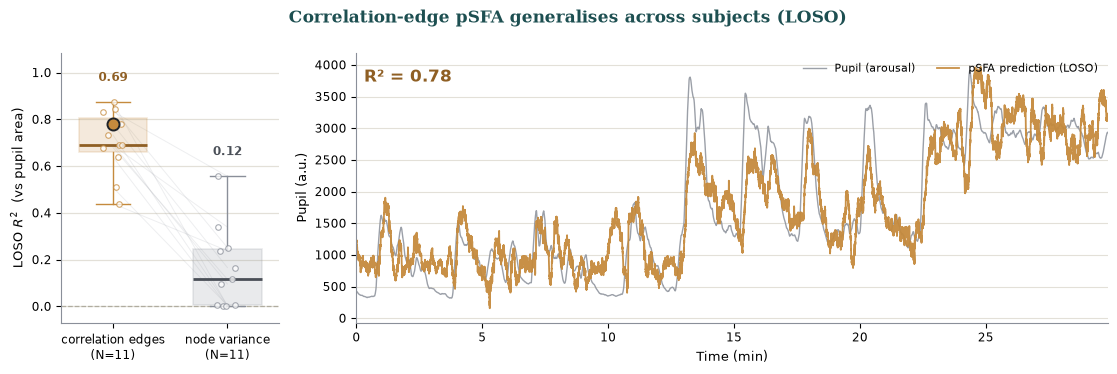

Plotted subject: 778998620  (correlation-edge LOSO R2 = 0.778)   [best subject overall: 789848216]
median LOSO R2: correlation edges = 0.691   node variance = 0.116


In [5]:
SELECTED_SID = '778998620' # set to a subject id string in F_corr to plot that subject's cold LOSO prediction; None = auto-pick best

gdf_loso    = drop_corrupted(loso_df)
corr_vals_l = gdf_loso["R2_corr"].dropna().values
nv_vals_l   = gdf_loso["R2_nodevar"].dropna().values

best_sid_l = gdf_loso["R2_corr"].idxmax()
plot_sid_l = SELECTED_SID if SELECTED_SID is not None else best_sid_l
if plot_sid_l not in F_corr:
    raise ValueError(f"{plot_sid_l!r} not in F_corr -- available: {sorted(F_corr)}")

tr_F_best  = [F_corr[s] for s in F_corr if s != plot_sid_l]
fit_best   = global_fit(tr_F_best, N_COMPONENTS)
w_best, mu_best = fit_best["W"][fit_best["best"]], fit_best["mu"]

y_raw_best = (F_corr[plot_sid_l] - mu_best) @ w_best
# ONLY affine_align use in this cell: scale/shift the cold cross-subject prediction into pupil units for the plot
y_pred_best, _, _ = affine_align(y_raw_best, d_corr[plot_sid_l])

_, d_raw_best, t_ds_best, _ = get_subject_pool(plot_sid_l)
half_l = (EDGE_WIN - 1) // 2
t_l = (t_ds_best[half_l: half_l + len(d_corr[plot_sid_l])] - t_ds_best[half_l]) / 60.0

fig = plt.figure(figsize=(13.5, 3.6))
gs  = fig.add_gridspec(1, 2, width_ratios=[0.55, 1.9], wspace=0.16, top=0.86)
axL = fig.add_subplot(gs[0]); axR = fig.add_subplot(gs[1])

all_vals = np.concatenate([corr_vals_l, nv_vals_l])
lo, hi = min(0.0, np.nanmin(all_vals)), np.nanmax(all_vals)
pad = 0.08 * (hi - lo)
label_off = 0.09 * (hi - lo)

axL.set_axisbelow(True); axL.yaxis.grid(True, color=RULE, lw=0.9)
groups = [(corr_vals_l, GOLD, GOLD_D), (nv_vals_l, MUTED, INK_SOFT)]
rng = np.random.default_rng(0)
for pos, (vals, col, cold) in enumerate(groups, 1):
    bp = axL.boxplot(vals, positions=[pos], widths=0.6, patch_artist=True,
                      showfliers=False, whis=(0, 100),
                      medianprops=dict(color=cold, lw=2.0), boxprops=dict(edgecolor=col, lw=1.2),
                      whiskerprops=dict(color=col, lw=1.0), capprops=dict(color=col, lw=1.0))
    bp["boxes"][0].set_facecolor(col); bp["boxes"][0].set_alpha(0.18)
    axL.scatter(np.full(len(vals), pos) + rng.uniform(-0.09, 0.09, len(vals)), vals, s=16,
                color="white", edgecolors=col, linewidths=0.8, zorder=3, alpha=0.75)
    axL.text(pos, vals.max() + label_off, f"{np.median(vals):.2f}", va="bottom", ha="center",
             fontsize=8.5, color=cold, fontweight="bold")
# faded lines connecting each subject's pair of values across the two categories
for sid in gdf_loso.index:
    v_corr, v_nv = gdf_loso.loc[sid, "R2_corr"], gdf_loso.loc[sid, "R2_nodevar"]
    if np.isfinite(v_corr) and np.isfinite(v_nv):
        axL.plot([1, 2], [v_corr, v_nv], color=MUTED, alpha=0.15, lw=0.7, zorder=1)
# highlight the plotted subject's correlation-edges point only (not node variance)
if plot_sid_l in gdf_loso.index:
    v_corr_hl = gdf_loso.loc[plot_sid_l, "R2_corr"]
    axL.scatter([1], [v_corr_hl], s=75, facecolor=GOLD, edgecolors=INK, linewidths=1.4, zorder=4)
axL.axhline(0, color="#b0ac9f", lw=0.9, ls="--", zorder=1)
axL.set_xticks([1, 2])
axL.set_xticklabels([f"correlation edges\n(N={len(corr_vals_l)})", f"node variance\n(N={len(nv_vals_l)})"], fontsize=8.5)
axL.set_xlim(0.55, 2.45)
axL.set_ylim(lo - pad, hi + pad + label_off * 1.8)
axL.set_ylabel(r"LOSO $R^2$  (vs pupil area)", fontsize=9.5)
axL.tick_params(labelsize=8.5)
axL.spines[["top", "right"]].set_visible(False); axL.spines[["left", "bottom"]].set_color(MUTED)

axR.set_axisbelow(True); axR.yaxis.grid(True, color=RULE, lw=0.8)
axR.plot(t_l, d_corr[plot_sid_l], color=MUTED, lw=1.0, alpha=0.85, label="Pupil (arousal)")
axR.plot(t_l, y_pred_best,        color=GOLD,  lw=1.3, alpha=0.95, label="pSFA prediction (LOSO)")
axR.text(0.01, 0.94, f"R\u00b2 = {gdf_loso.loc[plot_sid_l, 'R2_corr']:.2f}",
         transform=axR.transAxes, ha="left", va="top", fontsize=12, color=GOLD_D, fontweight="bold")
axR.set_xlim(t_l.min(), t_l.max()); axR.margins(y=0.06)
axR.set_xlabel("Time (min)", fontsize=9.5); axR.set_ylabel("Pupil (a.u.)", fontsize=9.5)
axR.tick_params(labelsize=8.5)
axR.legend(loc="upper right", frameon=False, fontsize=8, ncol=2)
axR.spines[["top", "right"]].set_visible(False); axR.spines[["left", "bottom"]].set_color(MUTED)

fig.suptitle("Correlation-edge pSFA generalises across subjects (LOSO)",
             fontfamily="serif", color=ACCENT_D, fontsize=12, fontweight="semibold", y=0.98)
fname = "fig3c_loso" if plot_sid_l == best_sid_l else f"fig3c_loso_{plot_sid_l}"
fig.savefig(MEDIA_DIR / f"{fname}.svg", transparent=True, bbox_inches="tight")
fig.savefig(MEDIA_DIR / f"{fname}.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()

print(f"Plotted subject: {plot_sid_l}  (correlation-edge LOSO R2 = {gdf_loso.loc[plot_sid_l, 'R2_corr']:.3f})   [best subject overall: {best_sid_l}]")
print(f"median LOSO R2: correlation edges = {np.median(corr_vals_l):.3f}   node variance = {np.median(nv_vals_l):.3f}")

## Panel D — Spatial map

Edge–pupil association in cortical space, correlation edges only. Each subject contributes the
area-pairs it has canonical VIS-area recordings for (2–6 of `CANON`); the plotted color is the
across-subject median correlation. **Color is the only channel encoding the correlation
value — no edge-thickness/size scaling by `|r|`** (unlike the source notebook's cortex-map
function, which redundantly scaled both).

In [6]:
from collections import defaultdict

edge_r_pupil = defaultdict(list)

for sid in subjects:
    out = load_subject_lfp(DATA_ROOT / sid, DOWNSAMPLE_FACTOR, area_filter=CANON, strict=False)
    if out is None:
        continue
    X_s, d_s, t_s, areas_s = out
    N = len(areas_s)
    keys = [(areas_s[i], areas_s[j]) for i in range(N) for j in range(i + 1, N)]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        Rho = build_feature("edges-corr", X_s, EDGE_WIN)
    d_sm = moving_average_centered(d_s[:, None], EDGE_WIN)[:, 0]
    n = min(len(d_sm), Rho.shape[0])
    if Rho.shape[1] != len(keys):
        print(f"  {sid}: feature width {Rho.shape[1]} != {len(keys)} keys -- skip")
        continue
    Rho_, d_ = Rho[:n], d_sm[:n]

    for k, key in enumerate(keys):
        edge_r_pupil[key].append(pearson_r(Rho_[:, k], d_))

print(f"{len(edge_r_pupil)} area-pair(s) with at least one contributing subject.")


15 area-pair(s) with at least one contributing subject.


findfont: Failed to find font weight semibold, now using 700.


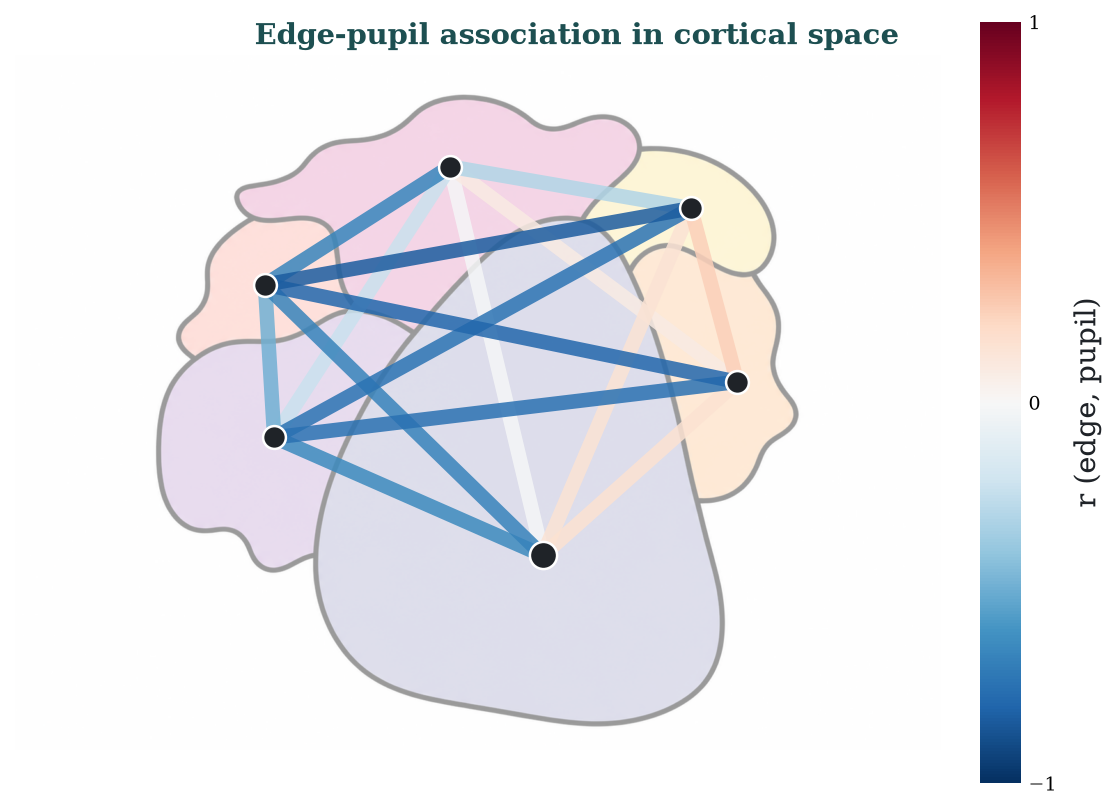

,n,median_r
VISpxVISl,10.0,-0.635
VISpxVISrl,16.0,-0.011
VISpxVISal,16.0,-0.668
VISpxVISam,18.0,0.148
VISlxVISrl,10.0,-0.221
VISlxVISal,9.0,-0.482
VISlxVISam,10.0,-0.739
VISrlxVISal,15.0,-0.657
VISrlxVISam,15.0,-0.297
VISalxVISam,15.0,-0.833


In [7]:
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

R_CMAP = plt.cm.RdBu_r          # -1 = blue, 0 = white, +1 = red
R_NORM = Normalize(vmin=-1, vmax=1)


def draw_cortex_pupil_r_edges(ax, r_pupil, pos, bg=None, cmap=R_CMAP, norm=R_NORM,
                               lw=7.0, img_alpha=0.4, cax=None):
    """Edge-weighted cortex diagram: edge COLOR encodes the across-subject median
    correlation with pupil on a fixed, absolute [-1, 1] scale (RdBu_r)
    """
    med = {p: float(np.median(rs)) for p, rs in r_pupil.items() if p[0] in pos and p[1] in pos}

    h, w = bg.shape[:2] if bg is not None else (1, 1)
    to_px = lambda xy: (xy[0] * w, (1 - xy[1]) * h)

    if bg is not None:
        ax.imshow(bg, origin='upper', alpha=img_alpha, zorder=0, interpolation='bilinear')
        ax.set_xlim(0, w)
        ax.set_ylim(h, 0)

    for (a, b), r in sorted(med.items(), key=lambda kv: abs(kv[1])):
        col = cmap(norm(r))
        (x1, y1), (x2, y2) = to_px(pos[a]), to_px(pos[b])
        ax.plot([x1, x2], [y1, y2], color=col, lw=lw, alpha=0.85,
                solid_capstyle='round', zorder=2)

    for a, xy in pos.items():
        x, y = to_px(xy)
        ax.scatter([x], [y], s=170 if a == 'VISp' else 120, facecolor=INK,
                   edgecolor='white', linewidths=1.2, zorder=3)

    ax.set_aspect('equal')
    ax.axis('off')

    if cax is not None:
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cb = ax.figure.colorbar(sm, cax=cax, orientation='vertical')
        cb.set_ticks([-1, 0, 1])
        cb.ax.tick_params(labelsize=9, length=0)
        for lab in cb.ax.get_yticklabels():
            lab.set_fontfamily('serif')
        cb.outline.set_visible(False)
        cb.set_label("r (edge, pupil)", fontsize=14, labelpad=8, color=INK, fontfamily='serif')


fig = plt.figure(figsize=(7.8, 5.4), dpi=150)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 0.045], wspace=0.08,
                       left=0.02, right=0.88, bottom=0.04, top=0.98)
ax = fig.add_subplot(gs[0])
cax = fig.add_subplot(gs[1])

draw_cortex_pupil_r_edges(ax, edge_r_pupil, pos=POS, bg=BG_IMAGE, cax=cax)
fig.suptitle("Edge-pupil association in cortical space",
             fontfamily="serif", color=ACCENT_D, fontsize=14, fontweight="semibold", y=0.98)
fig.savefig(MEDIA_DIR / "fig3d_spatial_map.svg", transparent=True, bbox_inches="tight")
fig.savefig(MEDIA_DIR / "fig3d_spatial_map.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()

edge_r_summary = pd.DataFrame(
    {"x".join(k): dict(n=len(v), median_r=np.median(v)) for k, v in edge_r_pupil.items()}
).T
edge_r_summary.to_csv(CACHE_DIR / "spatial_map_edge_r_smoothed.csv")
display(edge_r_summary.round(3))

## Appendix

### A1 — Reconstruction accuracy vs. window length

Reuses the already-cached sweep from `full_window_sweep.ipynb` (`results/full_window_sweep.csv`,
21 window sizes x 13 features x SFA/PCA x smoothed/unsmoothed pupil target) -- filtered down to
just correlation edges and node variance, scored against the raw (unsmoothed) pupil, up to 60s.

findfont: Failed to find font weight semibold, now using 700.


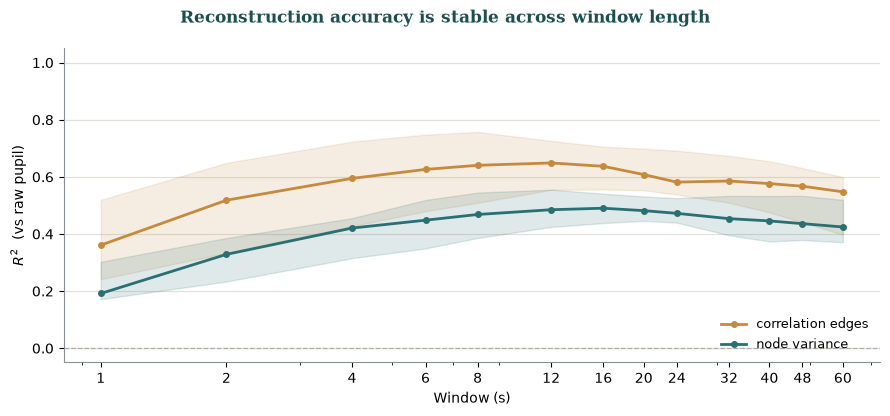

In [8]:
sweep_df = pd.read_csv(CACHE_DIR / "full_window_sweep.csv")
sub = sweep_df[
    sweep_df["feature"].isin(["edges-corr", "node-var"])
    & (sweep_df["method"] == "sfa")
    & (sweep_df["target_mode"] == "unsmoothed")
    & (sweep_df["window_s"] <= 60)
]

FEATS_A1 = [("edges-corr", "correlation edges", GOLD), ("node-var", "node variance", ACCENT)]
window_grid = sorted(sub["window_s"].unique())

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.set_axisbelow(True); ax.yaxis.grid(True, color=RULE, lw=0.9)
for feat, label, col in FEATS_A1:
    med, lo, hi = [], [], []
    for w in window_grid:
        vals = sub[(sub["feature"] == feat) & (sub["window_s"] == w)]["R2"].dropna()
        med.append(vals.median()); lo.append(vals.quantile(0.25)); hi.append(vals.quantile(0.75))
    ax.plot(window_grid, med, color=col, lw=2.0, marker="o", ms=4, label=label)
    ax.fill_between(window_grid, lo, hi, color=col, alpha=0.15)
ax.axhline(0, color="#b0ac9f", lw=0.9, ls="--", zorder=1)
ax.set_xscale("log")
ax.set_xticks(window_grid); ax.set_xticklabels([str(int(w)) for w in window_grid])
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Window (s)"); ax.set_ylabel(r"$R^2$  (vs raw pupil)")
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False); ax.spines[["left", "bottom"]].set_color(MUTED)
fig.suptitle("Reconstruction accuracy is stable across window length",
             fontfamily="serif", color=ACCENT_D, fontsize=12.5, fontweight="semibold", y=0.98)
fig.tight_layout()
fig.savefig(MEDIA_DIR / "fig_appendix_window_sweep.svg", transparent=True, bbox_inches="tight")
fig.savefig(MEDIA_DIR / "fig_appendix_window_sweep.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()


### A2 — IAAFT surrogate control

IAAFT (Schreiber & Schmitz 1996) surrogates independently randomize each channel's Fourier
phases, exactly preserving that channel's own power spectrum and amplitude distribution while
destroying cross-channel coupling. If reconstruction collapses on the surrogate, the real result
depended on genuine inter-area coupling, not single-channel structure "leaking" into the edges.

Computed fresh at 12s (matching this notebook's `EDGE_WIN`) rather than reusing the older ~24s
cache in `PINUP/LFP_notebooks/iaaft_control.csv`. This machinery is kept local to this notebook
(not added to `src/`) since it's a one-off appendix check, not something else in the repo needs.

In [9]:
import time
from sksfa import SFA
from sklearn.decomposition import PCA

IAAFT_WIN         = 1500   # 12 s exactly -- nicely composite (no FFT slowdown), so no need
                           # for the "-1 sample" prime-avoidance trick EDGE_WIN=1501 uses
IAAFT_STRIDE      = IAAFT_WIN   # sweep is ALWAYS non-overlapping (overlap would give the real
                                # feature series "free" extra autocorrelation surrogates don't get)
N_SURROGATES      = 20
IAAFT_NITER       = 25
IAAFT_RANDOM_SEED = 0


def iaaft_surrogate_batch(X, n_iter=None, rng=None, amp=None, x_sorted=None):
    """IAAFT surrogate for each COLUMN of X, independently -- preserves each channel's own
    power spectrum + amplitude distribution, destroys cross-channel coupling."""
    if n_iter is None:
        n_iter = IAAFT_NITER
    X = np.asarray(X, float)
    L, K = X.shape
    if rng is None:
        rng = np.random.default_rng()
    if amp is None:
        amp = np.abs(np.fft.rfft(X, axis=0))
    if x_sorted is None:
        x_sorted = np.sort(X, axis=0)
    s = np.empty_like(X)
    for k in range(K):
        s[:, k] = rng.permutation(X[:, k])
    for _ in range(n_iter):
        phases = np.angle(np.fft.rfft(s, axis=0))
        s = np.fft.irfft(amp * np.exp(1j * phases), n=L, axis=0)
        ranks = np.argsort(np.argsort(s, axis=0), axis=0)
        s = np.take_along_axis(x_sorted, ranks, axis=0)
    return s


def extract_windows(X, win=None, stride=None):
    win = IAAFT_WIN if win is None else win
    stride = IAAFT_STRIDE if stride is None else stride
    T, N = X.shape
    starts = np.arange(0, T - win + 1, stride)
    W = np.stack([X[s:s + win] for s in starts], axis=0)
    return W, starts


def pupil_per_window(d, starts, win=None):
    win = IAAFT_WIN if win is None else win
    return np.array([d[s:s + win].mean() for s in starts])


def features_from_windows(W):
    """Per-window BLOCK features (np.corrcoef/np.cov/.var() on each window) -- a different,
    block-based style than the rolling build_feature("edges-corr", ...) used elsewhere, since IAAFT
    needs discrete independent blocks to surrogate."""
    n_win, win, N = W.shape
    pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]
    node_var = W.var(axis=1)
    corr = np.empty((n_win, len(pairs)))
    cov = np.empty((n_win, len(pairs)))
    for w in range(n_win):
        C = np.corrcoef(W[w], rowvar=False)
        V = np.cov(W[w], rowvar=False)
        for k, (i, j) in enumerate(pairs):
            corr[w, k] = C[i, j]
            cov[w, k] = V[i, j]
    return node_var, corr, cov, pairs


def prep_surrogate(W):
    n_win, win, N = W.shape
    flat = np.transpose(W, (1, 0, 2)).reshape(win, n_win * N).copy()
    return {"shape": (n_win, win, N), "flat": flat,
            "amp": np.abs(np.fft.rfft(flat, axis=0)), "x_sorted": np.sort(flat, axis=0)}


def surrogate_windows(W, rng, n_iter=None, prep=None):
    if prep is None:
        prep = prep_surrogate(W)
    n_win, win, N = prep["shape"]
    surr = iaaft_surrogate_batch(prep["flat"], n_iter=n_iter, rng=rng,
                                 amp=prep["amp"], x_sorted=prep["x_sorted"])
    return np.transpose(surr.reshape(win, n_win, N), (1, 0, 2))


def _c0(F, d_sm, n_comp, use_sfa):
    k = min(n_comp, F.shape[1])
    model = SFA(n_components=k, fill_mode="zero") if use_sfa else PCA(n_components=k)
    yf, _, _ = affine_align(model.fit_transform(F)[:, 0], d_sm)
    return r2_score(d_sm, yf)


def score_features(node_var, corr, cov, d_win, n_comp=N_COMPONENTS, use_sfa=True):
    return {
        "corr":    _c0(corr,     d_win, n_comp, use_sfa),
        "cov":     _c0(cov,      d_win, n_comp, use_sfa),
        "nodevar": _c0(node_var, d_win, n_comp, use_sfa),
    }

print(f"IAAFT window = {IAAFT_WIN} samples = {IAAFT_WIN/(1250/DOWNSAMPLE_FACTOR):.0f} s "
      f"at {1250//DOWNSAMPLE_FACTOR} Hz")


IAAFT window = 1500 samples = 12 s at 125 Hz


In [ ]:
rng_master = np.random.default_rng(IAAFT_RANDOM_SEED)
iaaft_rows = []
t0 = time.time()
for sid in subjects:
    if sid in CORRUPTED_SIDS:
        continue
    out = load_subject_lfp(DATA_ROOT / sid, DOWNSAMPLE_FACTOR, area_filter=None)
    if out is None:
        continue
    X_s, d_s, t_s, areas_s = out
    W, starts = extract_windows(X_s, win=IAAFT_WIN, stride=IAAFT_STRIDE)
    d_win = pupil_per_window(d_s, starts, win=IAAFT_WIN)
    nv, cr, cv, pairs = features_from_windows(W)
    prep = prep_surrogate(W)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        real = score_features(nv, cr, cv, d_win)
        draws = {k: [] for k in real}
        for _ in range(N_SURROGATES):
            Ws = surrogate_windows(W, rng_master, prep=prep)
            nvs, crs, cvs, _ = features_from_windows(Ws)
            sc = score_features(nvs, crs, cvs, d_win)
            for k in sc:
                draws[k].append(sc[k])

    row = {"subject": sid, "n_win": len(starts)}
    for k in real:
        arr = np.array(draws[k])
        row[f"real_{k}"] = real[k]
        row[f"surr_{k}_med"] = float(np.median(arr))
    iaaft_rows.append(row)
    print(f"  {sid}: " + "  ".join(f"{k}: real={real[k]:.2f} surr={np.median(draws[k]):.2f}" for k in real))

print(f"\nSweep done in {time.time()-t0:.0f}s")
iaaft_df = pd.DataFrame(iaaft_rows).set_index("subject")
iaaft_df.to_csv(CACHE_DIR / "iaaft_control_12s.csv")
display(iaaft_df.round(3))


  766640955: corr: real=0.53 surr=0.01  cov: real=0.41 surr=0.00  nodevar: real=0.39 surr=0.39
  767871931: corr: real=0.72 surr=0.01  cov: real=0.68 surr=0.02  nodevar: real=0.70 surr=0.70
  771160300: corr: real=0.81 surr=0.01  cov: real=0.73 surr=0.01  nodevar: real=0.60 surr=0.60
  771990200: corr: real=0.60 surr=0.01  cov: real=0.72 surr=0.00  nodevar: real=0.62 surr=0.62
  774875821: corr: real=0.62 surr=0.01  cov: real=0.59 surr=0.01  nodevar: real=0.56 surr=0.56


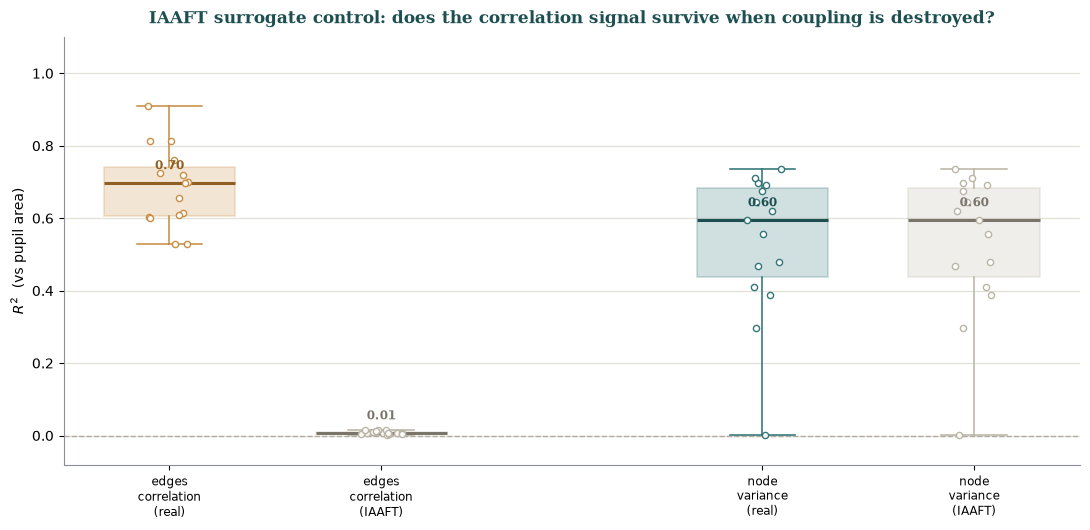


── Median across subjects (real -> surrogate) ──
  corr    : real 0.698  ->  IAAFT 0.007   (drop +0.691)
  nodevar : real 0.595  ->  IAAFT 0.595   (drop +0.000)


In [11]:
SURRC='#b9b2a3'; SURRC_D='#7a746a'

feats_iaaft = [
    ("edges\ncorrelation", "corr", GOLD, GOLD_D),
    # ("edges\ncovariance",  "cov",  GOLD, GOLD_D),
    ("node\nvariance",     "nodevar", ACCENT, ACCENT_D),
]

fig, ax = plt.subplots(figsize=(11, 5.4))
ax.set_axisbelow(True); ax.yaxis.grid(True, color=RULE, lw=0.9)
ax.set_ylim(-0.08, 1.10); ax.set_yticks(np.arange(0, 1.01, 0.2))

pos = 1
xticks, xlabels = [], []
rng = np.random.default_rng(0)
for lab, key, col, cold in feats_iaaft:
    real = iaaft_df[f"real_{key}"].dropna().values
    surr = iaaft_df[f"surr_{key}_med"].dropna().values
    for j, (vals, c, cd, tag) in enumerate([(real, col, cold, "real"), (surr, SURRC, SURRC_D, "IAAFT")]):
        p = pos + j
        bp = ax.boxplot(vals, positions=[p], widths=0.62, patch_artist=True,
                        showfliers=False, whis=(0, 100),
                        medianprops=dict(color=cd, lw=2.2), boxprops=dict(edgecolor=c, lw=1.3),
                        whiskerprops=dict(color=c, lw=1.1), capprops=dict(color=c, lw=1.1))
        bp['boxes'][0].set_facecolor(c); bp['boxes'][0].set_alpha(0.22)
        ax.scatter(np.full(len(vals), p) + rng.uniform(-0.10, 0.10, len(vals)), vals,
                   s=20, color='white', edgecolors=c, linewidths=1.0, zorder=3, alpha=0.95)
        ax.text(p, np.median(vals) + 0.03, f'{np.median(vals):.2f}', ha='center', va='bottom',
                fontsize=8.5, color=cd, fontweight='bold')
        xticks.append(p); xlabels.append(f"{lab}\n({tag})")
    pos += 2.8

ax.axhline(0, color='#b0ac9f', lw=1, ls='--', zorder=1)
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, fontsize=8.5)
ax.set_ylabel(r'$R^2$  (vs pupil area)')
ax.set_title('IAAFT surrogate control: does the correlation signal survive when coupling is destroyed?',
             fontfamily='serif', color=ACCENT_D, fontsize=12.5, fontweight='semibold', pad=10)
ax.spines[['top','right']].set_visible(False); ax.spines[['left','bottom']].set_color(MUTED)
fig.tight_layout()
fig.savefig(MEDIA_DIR / 'fig_appendix_iaaft_control.svg', transparent=True, bbox_inches='tight')
fig.savefig(MEDIA_DIR / 'fig_appendix_iaaft_control.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

print("\n── Median across subjects (real -> surrogate) ──")
for lab, key, *_ in feats_iaaft:
    r = iaaft_df[f"real_{key}"].median(); s = iaaft_df[f"surr_{key}_med"].median()
    print(f"  {key:8s}: real {r:.3f}  ->  IAAFT {s:.3f}   (drop {r - s:+.3f})")


### A3 — Covariance vs. correlation edges: direction and spatial map

Correlation edges cancel shared multiplicative gain by construction (normalized by each
channel's own variance); covariance edges do not. This should show up as correlation edges
having a consistent sign across area-pairs, while covariance edges are mixed/inconsistent.

In [12]:
from scipy import stats

edge_r_cov  = defaultdict(list)
edge_r_corr = defaultdict(list)

for sid in subjects:
    out = load_subject_lfp(DATA_ROOT / sid, DOWNSAMPLE_FACTOR, area_filter=CANON, strict=False)
    if out is None:
        continue
    X_s, d_s, t_s, areas_s = out
    N = len(areas_s)
    pairs = [(i, j) for i in range(N) for j in range(i + 1, N)]

    d_sm = moving_average_centered(d_s[:, None], EDGE_WIN)[:, 0]
    E_cov_raw, _ = build_edges(X_s)
    E_cov = moving_average_centered(E_cov_raw - E_cov_raw.mean(axis=0, keepdims=True), EDGE_WIN)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        Rho = build_feature("edges-corr", X_s, EDGE_WIN)

    T = min(len(d_sm), E_cov.shape[0], Rho.shape[0])
    d_T, E_cov_T, Rho_T = d_sm[:T], E_cov[:T], Rho[:T]

    for k, (i, j) in enumerate(pairs):
        edge_r_cov[(areas_s[i], areas_s[j])].append(pearson_r(E_cov_T[:, k], d_T))
        edge_r_corr[(areas_s[i], areas_s[j])].append(pearson_r(Rho_T[:, k], d_T))

print(f"{len(edge_r_corr)} area-pair(s) with at least one contributing subject.")


15 area-pair(s) with at least one contributing subject.


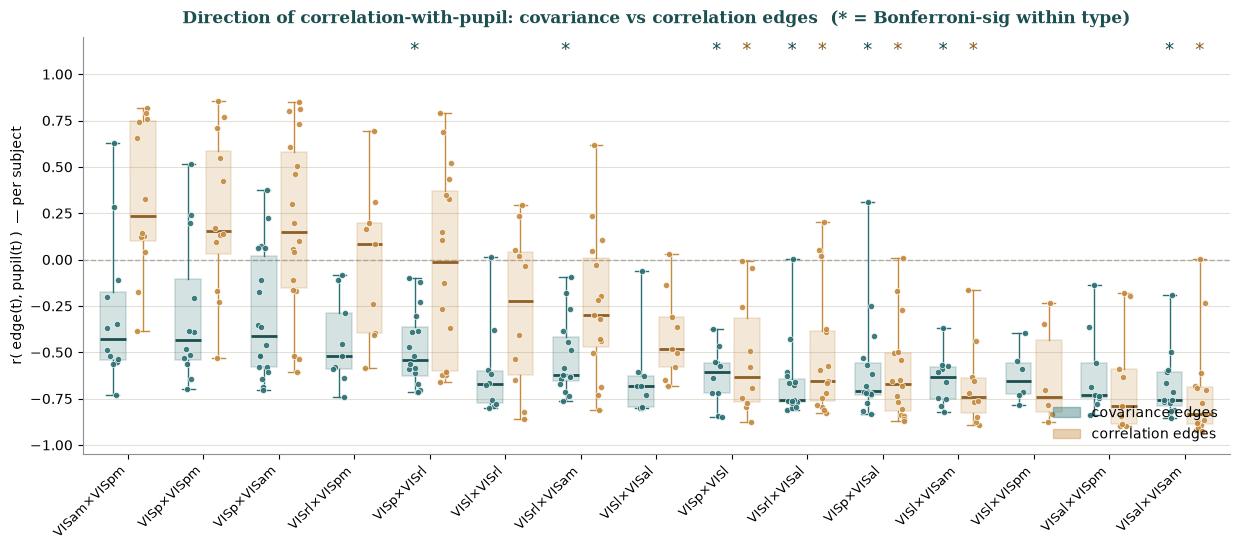

In [13]:
def summarize_direction(edge_r):
    rows = []
    for p, rs in edge_r.items():
        rs = np.array(rs)
        try:
            _, pval = stats.wilcoxon(rs)
        except ValueError:
            pval = np.nan
        rows.append({"edge": f"{p[0]}×{p[1]}", "n": len(rs), "median_r": np.median(rs),
                      "n_pos": int((rs > 0).sum()), "n_neg": int((rs < 0).sum()), "p_raw": pval})
    df = pd.DataFrame(rows)
    df["p_bonf"] = np.minimum(df["p_raw"] * len(df), 1.0)
    df["sig_bonf"] = df["p_bonf"] < 0.05
    return df.set_index("edge")

summary_cov  = summarize_direction(edge_r_cov)
summary_corr = summarize_direction(edge_r_corr)

order = summary_corr.sort_values("median_r", ascending=False).index.tolist()
pos_x = np.arange(len(order))
cov_d  = [edge_r_cov[tuple(e.split("×"))]  for e in order]
corr_d = [edge_r_corr[tuple(e.split("×"))] for e in order]

def _style_box(bp, col, cold):
    for b in bp["boxes"]:    b.set_facecolor(col); b.set_alpha(0.20); b.set_edgecolor(col); b.set_linewidth(1.1)
    for md_ in bp["medians"]: md_.set_color(cold); md_.set_linewidth(2)
    for w_ in bp["whiskers"]: w_.set_color(col); w_.set_linewidth(1)
    for c_ in bp["caps"]:     c_.set_color(col); c_.set_linewidth(1)

fig, ax = plt.subplots(figsize=(12.5, 5.6))
ax.set_axisbelow(True); ax.yaxis.grid(True, color=RULE, lw=0.8)
ax.axhline(0, color="#b0ac9f", lw=1, ls="--", zorder=1)
ax.set_ylim(-1.05, 1.2)

bp_cov  = ax.boxplot(cov_d,  positions=pos_x - 0.20, widths=0.34, patch_artist=True, showfliers=False, whis=(0, 100), zorder=2)
bp_corr = ax.boxplot(corr_d, positions=pos_x + 0.20, widths=0.34, patch_artist=True, showfliers=False, whis=(0, 100), zorder=2)
_style_box(bp_cov,  ACCENT, ACCENT_D)
_style_box(bp_corr, GOLD,   GOLD_D)

rng = np.random.default_rng(0)
for xi, e in enumerate(order):
    rs_cov  = np.array(edge_r_cov[tuple(e.split("×"))])
    rs_corr = np.array(edge_r_corr[tuple(e.split("×"))])
    ax.scatter(xi - 0.20 + rng.uniform(-0.08, 0.08, len(rs_cov)),  rs_cov,  s=20, color=ACCENT, edgecolors="white", linewidths=0.5, zorder=3, alpha=0.9)
    ax.scatter(xi + 0.20 + rng.uniform(-0.08, 0.08, len(rs_corr)), rs_corr, s=20, color=GOLD,   edgecolors="white", linewidths=0.5, zorder=3, alpha=0.9)
    if summary_cov.loc[e, "sig_bonf"]:
        ax.text(xi - 0.20, 1.08, "*", ha="center", va="bottom", fontsize=13, color=ACCENT_D)
    if summary_corr.loc[e, "sig_bonf"]:
        ax.text(xi + 0.20, 1.08, "*", ha="center", va="bottom", fontsize=13, color=GOLD_D)

ax.set_xticks(pos_x)
ax.set_xticklabels(order, rotation=45, ha="right", fontsize=9)
ax.set_xlim(-0.6, len(order) - 0.4)
ax.set_ylabel("r( edge(t), pupil(t) )  — per subject")
ax.set_title("Direction of correlation-with-pupil: covariance vs correlation edges  (* = Bonferroni-sig within type)",
              fontfamily="serif", color=ACCENT_D, fontsize=12.5, fontweight="semibold", pad=10)
ax.spines[["top", "right"]].set_visible(False); ax.spines[["left", "bottom"]].set_color(MUTED)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=ACCENT, alpha=0.4, edgecolor=ACCENT, label="covariance edges"),
                    Patch(facecolor=GOLD,   alpha=0.4, edgecolor=GOLD,   label="correlation edges")],
          loc="lower right", frameon=False, fontsize=10)
fig.tight_layout()
fig.savefig(MEDIA_DIR / "fig_appendix_direction_cov_vs_corr.svg", transparent=True, bbox_inches="tight")
fig.savefig(MEDIA_DIR / "fig_appendix_direction_cov_vs_corr.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()


findfont: Failed to find font weight semibold, now using 700.


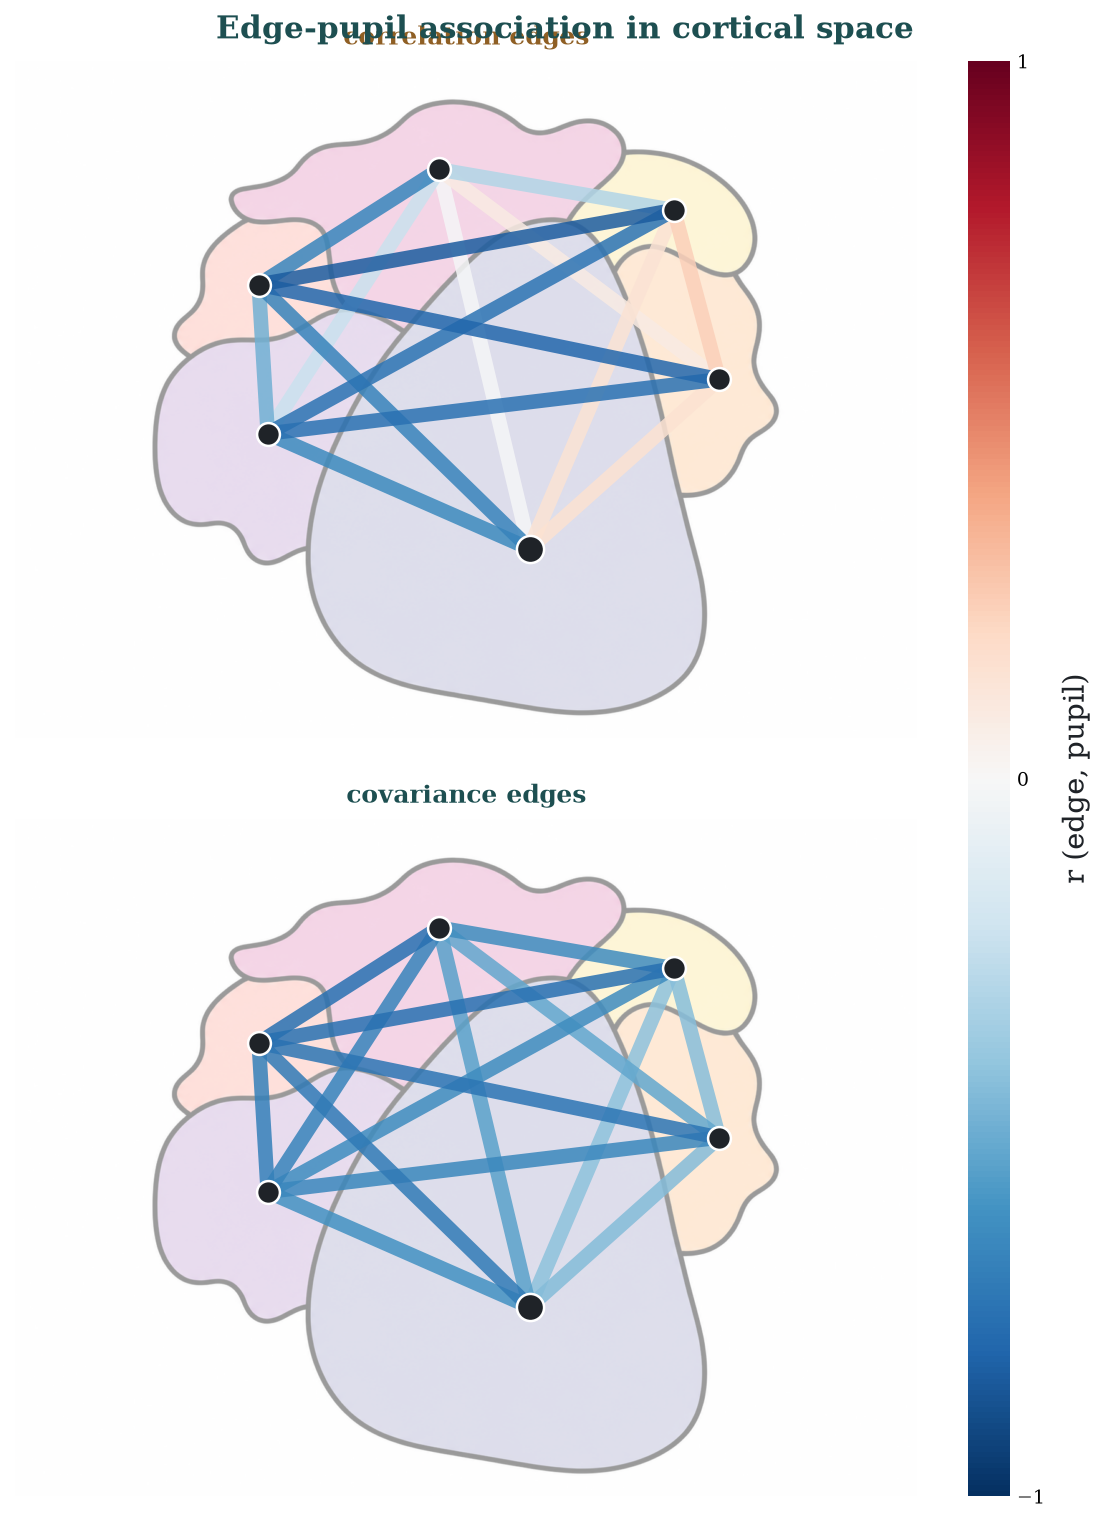

In [15]:
fig = plt.figure(figsize=(7.8, 10.4), dpi=150)
gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.045], height_ratios=[1, 1],
                       wspace=0.08, hspace=0.12, left=0.02, right=0.88, bottom=0.03, top=0.95)
ax_corr = fig.add_subplot(gs[0, 0])
ax_cov  = fig.add_subplot(gs[1, 0])
cax     = fig.add_subplot(gs[:, 1])

draw_cortex_pupil_r_edges(ax_corr, edge_r_pupil, pos=POS, bg=BG_IMAGE, cax=cax)
draw_cortex_pupil_r_edges(ax_cov,  edge_r_cov,   pos=POS, bg=BG_IMAGE)

ax_corr.set_title("correlation edges", fontfamily="serif", color=GOLD_D, fontsize=12, fontweight="semibold", pad=8)
ax_cov.set_title("covariance edges", fontfamily="serif", color=ACCENT_D, fontsize=12, fontweight="semibold", pad=8)

fig.suptitle("Edge-pupil association in cortical space",
             fontfamily="serif", color=ACCENT_D, fontsize=15, fontweight="semibold", y=0.98)
fig.savefig(MEDIA_DIR / "fig_appendix_spatial_map_cov_vs_corr.svg", transparent=True, bbox_inches="tight")
fig.savefig(MEDIA_DIR / "fig_appendix_spatial_map_cov_vs_corr.png", dpi=300, transparent=True, bbox_inches="tight")
plt.show()